In [2]:
#Importing the neccessary libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
#Importing the data set 
df = pd.read_csv(r"C:\Users\HP\Downloads\student_dropout_dataset_v3.csv")

In [4]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [5]:
df.shape

(10000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [7]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [8]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [9]:
#Now we can check the null values in the above dataset 
df.isna().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

Observation : The columns that are having the null values ['Family_Income','Study_Hours_per_day','Stress_Index','Parental_Education']

In [10]:
#Now we are going to check the duplicate values in the above data set 
df.duplicated().sum()

np.int64(0)

Observation : There are no Duplicate values in the above dataset 


In [11]:
#Data cleaning starts ; now we can go through each and every column to clean if it is messy  

#Defining a column to check the unique values in the column 
def find_unique(col_name):
    return df[col_name].unique() 

#Defining a function to check the null values in the column 
def find_nulls_sum(col_name):
    return df[col_name].isna().sum() 
#Defining a function to check the duplicate values in the column 

def find_duplicates_sum(col_name):
    return df[col_name].duplicated().sum() 

#Defining a function to check is there any trailing or leading spaces 
def find_trailing_leading_spaces(col_name):
    return df[df[col_name] != df[col_name].str.strip()] 


In [12]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [13]:
def column_audit(df, col_name):
    
    print(f"------ Column Audit: {col_name} ------\n")
    
    # Data type
    print("Data Type:")
    print(df[col_name].dtype)
    print()
    
    # Null values
    print("Null Values:")
    print(df[col_name].isna().sum())
    print()
    
    # Duplicate values
    print("Duplicate Values:")
    print(df[col_name].duplicated().sum())
    print()
    
    # Unique values
    print("Unique Values:")
    print(df[col_name].nunique())
    print()
    
    # Leading / trailing spaces
    if df[col_name].dtype == 'object':
        space_rows = df[df[col_name] != df[col_name].str.strip()]
        print("Rows with leading/trailing spaces:")
        print(len(space_rows))
        print()
    
    # Value counts
    print("Top Value Counts:")
    print(df[col_name].value_counts().head())
    print()
    
    # Numeric statistics
    if df[col_name].dtype != 'object':
        print("Statistical Summary:")
        print(df[col_name].describe())
    
    print("\n-------------------------------------")

In [14]:
column_audit(df,'Gender')

------ Column Audit: Gender ------

Data Type:
object

Null Values:
0

Duplicate Values:
9998

Unique Values:
2

Rows with leading/trailing spaces:
0

Top Value Counts:
Gender
Female    5011
Male      4989
Name: count, dtype: int64


-------------------------------------


In [15]:
#Generating a report for all columns with all data quality checks using the above column audit function 


for col in df.columns:
    column_audit(df, col) 

------ Column Audit: Student_ID ------

Data Type:
int64

Null Values:
0

Duplicate Values:
0

Unique Values:
10000

Top Value Counts:
Student_ID
10000    1
1        1
2        1
3        1
4        1
Name: count, dtype: int64

Statistical Summary:
count    10000.00000
mean      5000.50000
std       2886.89568
min          1.00000
25%       2500.75000
50%       5000.50000
75%       7500.25000
max      10000.00000
Name: Student_ID, dtype: float64

-------------------------------------
------ Column Audit: Age ------

Data Type:
float64

Null Values:
0

Duplicate Values:
9885

Unique Values:
115

Top Value Counts:
Age
17.0    371
20.9    208
20.5    197
21.7    191
21.4    187
Name: count, dtype: int64

Statistical Summary:
count    10000.00000
mean        21.02606
std          2.13981
min         17.00000
25%         19.50000
50%         21.00000
75%         22.50000
max         29.60000
Name: Age, dtype: float64

-------------------------------------
------ Column Audit: Gender ------


In [16]:
#Now We are going to check the outliers for the numerical columns  using the iqr method 
def count_outliers_iqr(df, col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((df[col_name] < lower) | (df[col_name] > upper)).sum()

In [17]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns 

num_cols

Index(['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day',
       'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes',
       'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout'],
      dtype='object')

In [18]:
#Outliers Detection using the Iqr menthod with percentage
for col in num_cols:
    print(col ,':',count_outliers_iqr(df,col)) 
    print()
    print('Percentage : ' ,count_outliers_iqr(df,col) / 10000 * 100 )
    print()

Student_ID : 0

Percentage :  0.0

Age : 33

Percentage :  0.33

Family_Income : 604

Percentage :  6.04

Study_Hours_per_Day : 86

Percentage :  0.86

Attendance_Rate : 57

Percentage :  0.5700000000000001

Assignment_Delay_Days : 25

Percentage :  0.25

Travel_Time_Minutes : 25

Percentage :  0.25

Stress_Index : 0

Percentage :  0.0

GPA : 0

Percentage :  0.0

Semester_GPA : 0

Percentage :  0.0

CGPA : 0

Percentage :  0.0

Dropout : 2354

Percentage :  23.54



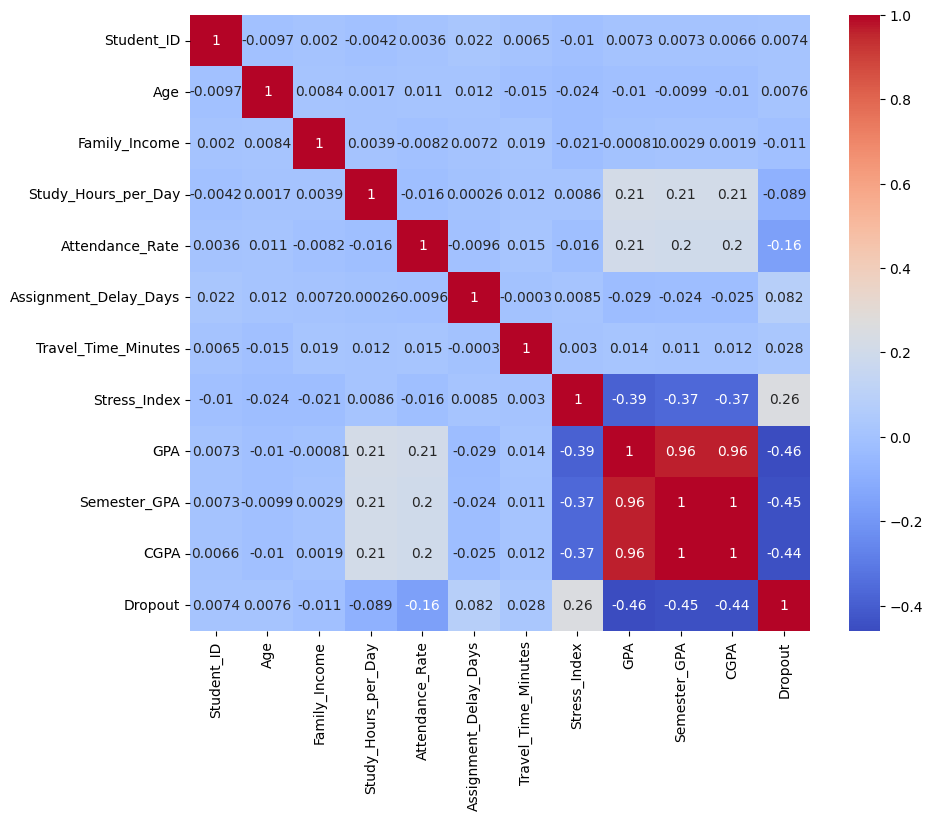

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

#Study hours show strong positive correlation with CGPA (0.71).

#Stress index has moderate negative correlation with GPA (-0.42).

#Attendance rate is positively associated with semester GPA (0.60).

array([[<Axes: title={'center': 'Student_ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Family_Income'}>],
       [<Axes: title={'center': 'Study_Hours_per_Day'}>,
        <Axes: title={'center': 'Attendance_Rate'}>,
        <Axes: title={'center': 'Assignment_Delay_Days'}>],
       [<Axes: title={'center': 'Travel_Time_Minutes'}>,
        <Axes: title={'center': 'Stress_Index'}>,
        <Axes: title={'center': 'GPA'}>],
       [<Axes: title={'center': 'Semester_GPA'}>,
        <Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Dropout'}>]], dtype=object)

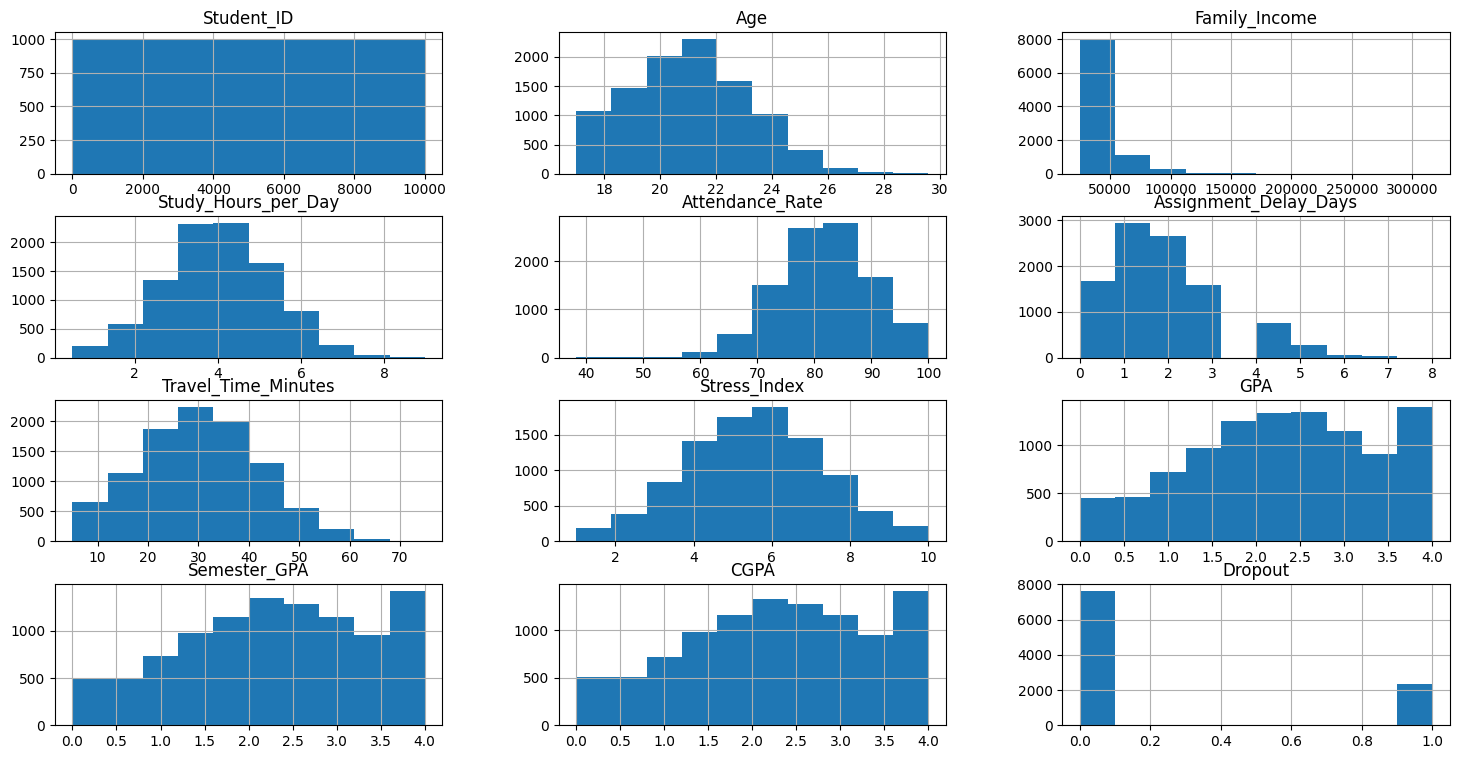

In [20]:
df.hist(figsize=(18,9))

array([[<Axes: title={'center': 'Student_ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Family_Income'}>],
       [<Axes: title={'center': 'Study_Hours_per_Day'}>,
        <Axes: title={'center': 'Attendance_Rate'}>,
        <Axes: title={'center': 'Assignment_Delay_Days'}>],
       [<Axes: title={'center': 'Travel_Time_Minutes'}>,
        <Axes: title={'center': 'Stress_Index'}>,
        <Axes: title={'center': 'GPA'}>],
       [<Axes: title={'center': 'Semester_GPA'}>,
        <Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Dropout'}>]], dtype=object)

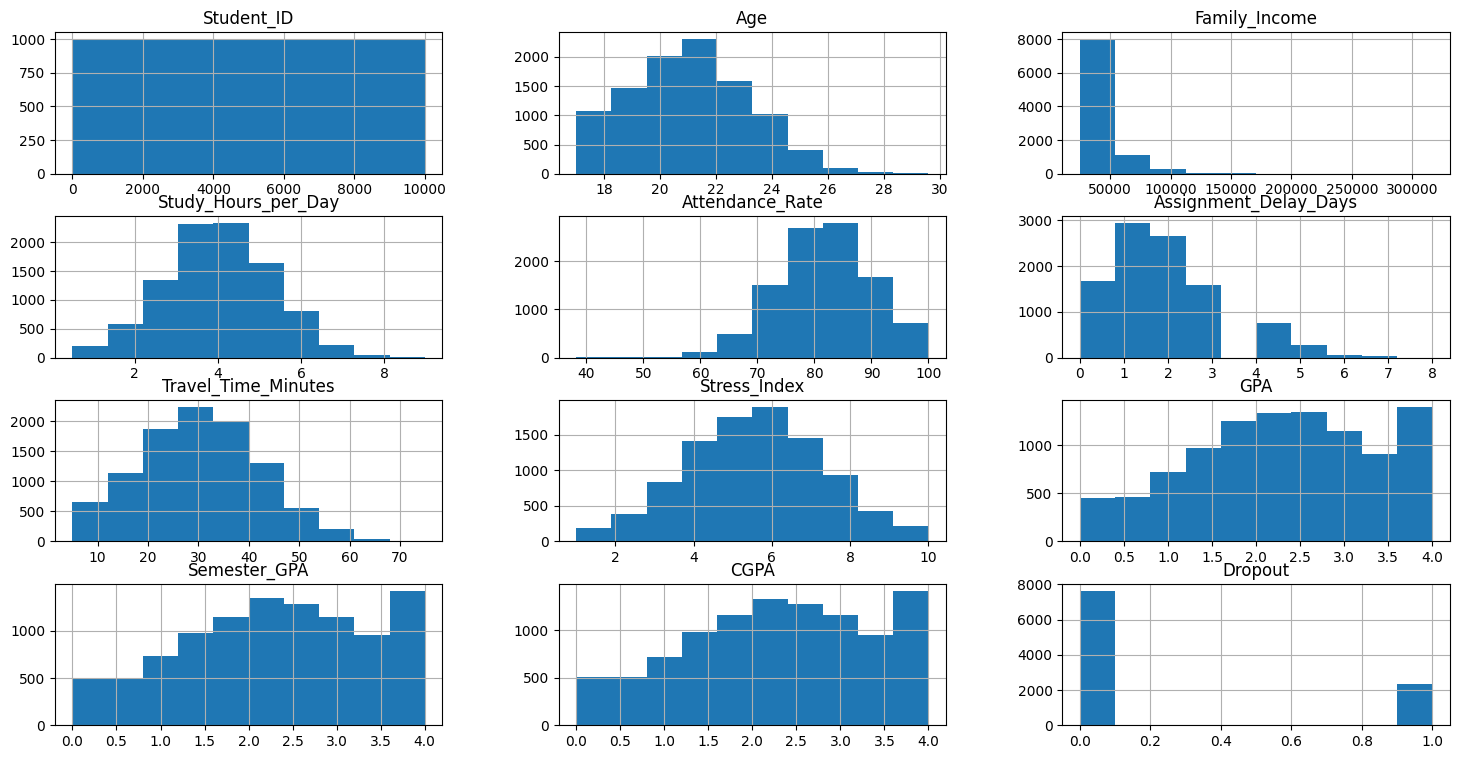

In [21]:
df.hist(figsize=(18,9))

In [22]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [23]:
#Now we are going to split the data 
from sklearn.model_selection import train_test_split

In [24]:
X = df.drop(['Dropout','Student_ID'],axis =1) 
y = df['Dropout']

In [25]:
X

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor
9996,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master
9997,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor
9998,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School


In [26]:
#Now splitting the data into training and testing 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42)

In [27]:
#Now creating the pipelines for the Data processing 
from imblearn.pipeline import Pipeline

In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [29]:
y.value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

In [30]:
#Now Creating a pipeline for datapreprocessing of the categorical columns
steps_1 = [('SimpleImputer',SimpleImputer(strategy='constant',fill_value='Unknown')) , ('Encoding',OneHotEncoder())]
categorical_preprocessor = Pipeline(steps_1)

In [31]:
categorical_preprocessor

Pipeline(steps=[('SimpleImputer',
                 SimpleImputer(fill_value='Unknown', strategy='constant')),
                ('Encoding', OneHotEncoder())])

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
#Creating the pipeline for the numerical_cols preprocessing 
steps_2 = [('SimpleIMputer',SimpleImputer(strategy='median')),('Scaling',StandardScaler()) ]
numerical_preprocessor = Pipeline(steps_2) 

In [34]:
numerical_preprocessor

Pipeline(steps=[('SimpleIMputer', SimpleImputer(strategy='median')),
                ('Scaling', StandardScaler())])

In [35]:
#Now creating a one pipeline that contain all the data preprocessing 
from sklearn.compose import ColumnTransformer

In [36]:
num_cols_1 = df.select_dtypes(include='number').columns
num_cols_1 = num_cols_1.drop(['Dropout','Student_ID'])
cat_cols_1 = df.select_dtypes(include='object').columns
preprocessor = ColumnTransformer(transformers=[('numerical',numerical_preprocessor,num_cols_1) , ('categorical',categorical_preprocessor,cat_cols_1)]) 

In [37]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('SimpleIMputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('SimpleImputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('Encoding',
                                                  OneHotEncoder())]),
                                 Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])

In [38]:
#Now Importing the models for testing the prediction 
from sklearn.linear_model import LogisticRegression

In [39]:
steps_3 = [('Preprocessing ' , preprocessor) , ('Smote',SMOTE()) , ('Classifier',LogisticRegression(max_iter=1000))]
model_1 = Pipeline(steps_3)

In [40]:
model_1

Pipeline(steps=[('Preprocessing ',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('SimpleIMputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('Encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])),
                ('Smote', SMOTE()),
                ('Classifier', LogisticRegression(max_iter=1000))])

In [41]:
#Now fitting the data into the model 
model_1.fit(X_train,y_train)

Pipeline(steps=[('Preprocessing ',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('SimpleIMputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('Encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])),
                ('Smote', SMOTE()),
                ('Classifier', LogisticRegression(max_iter=1000))])

In [42]:
#Importing the evalution metrics 
from sklearn.metrics import confusion_matrix,classification_report , precision_score,recall_score

In [43]:
y_pred = model_1.predict(X_test)

In [44]:
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(2000,))

In [45]:
cm = confusion_matrix(y_pred,y_test) 

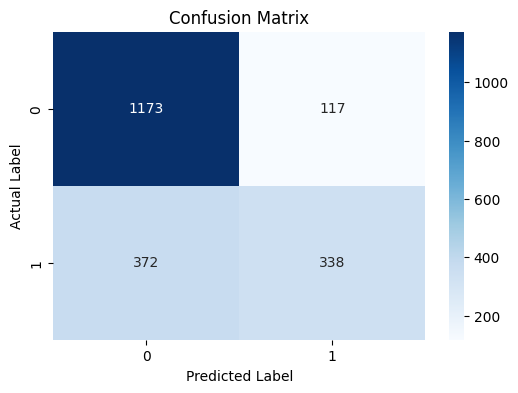

In [46]:

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [47]:


report = classification_report(y_test, y_pred, output_dict=True)

In [48]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

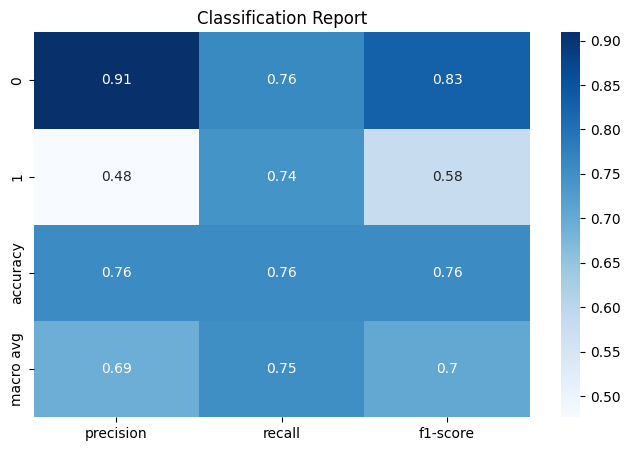

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues")

plt.title("Classification Report")
plt.show()

In [50]:
train_score = model_1.score(X_train, y_train)
test_score = model_1.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.74475
Testing Score: 0.7555


In [51]:
X_train.shape, X_test.shape

((8000, 17), (2000, 17))

In [52]:
y.value_counts(normalize=True)

Dropout
0    0.7646
1    0.2354
Name: proportion, dtype: float64

In [53]:
for col in df.columns:
    if col != 'Dropout':
        try:
            if (df[col].equals(df['Dropout'])):
                print("Leakage column:", col)
        except:
            pass 

In [54]:
(df['Family_Income'] == df['Dropout']).sum()

np.int64(0)

In [55]:
df.corr(numeric_only=True)['Dropout'].sort_values(ascending=False)

Dropout                  1.000000
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Age                      0.007585
Student_ID               0.007434
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64

In [56]:
precision_score(y_pred,y_test)

0.7428571428571429

In [57]:
recall_score(y_pred,y_test)

0.476056338028169

In [58]:
from sklearn.ensemble import RandomForestClassifier
steps_4 = [('Preprocessing ' , preprocessor) , ('Smote',SMOTE()) , ('Classifier',RandomForestClassifier())]
model_2 = Pipeline(steps_4)

In [59]:
model_2.fit(X_train,y_train)

Pipeline(steps=[('Preprocessing ',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('SimpleIMputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('Encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])),
                ('Smote', SMOTE()), ('Classifier', RandomForestClassifier())])

In [60]:
y_pred_2 = model_1.predict(X_test)

In [61]:
cm_2 = confusion_matrix(y_pred_2,y_test) 

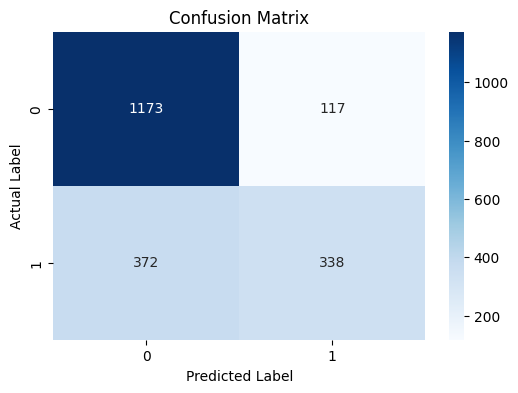

In [62]:
cm_2 = confusion_matrix(y_pred_2,y_test) 
plt.figure(figsize=(6,4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [63]:


report_2 = classification_report(y_test, y_pred_2, output_dict=True)

In [64]:
import pandas as pd

report_df_2 = pd.DataFrame(report).transpose()

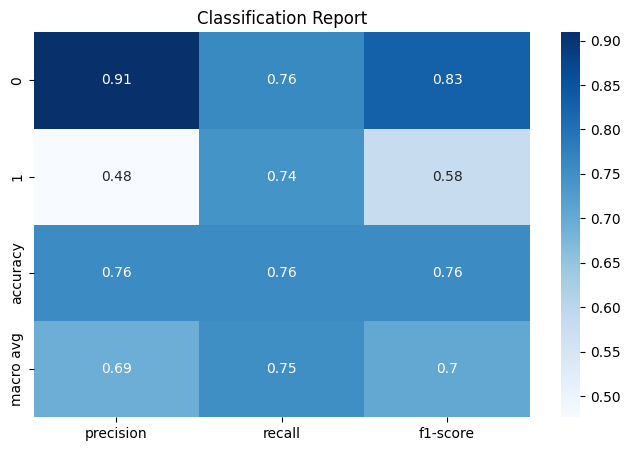

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt


report_3 = classification_report(y_test, y_pred_2, output_dict=True)
import pandas as pd

report_df_2 = pd.DataFrame(report).transpose()
plt.figure(figsize=(8,5))
sns.heatmap(report_df_2.iloc[:-1, :-1], annot=True, cmap="Blues")

plt.title("Classification Report")
plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier
steps_5 = [('Preprocessing ' , preprocessor) , ('Smote',SMOTE()) , ('Classifier',DecisionTreeClassifier())]
model_3 = Pipeline(steps_5)

In [67]:
steps_5

[('Preprocessing ',
  ColumnTransformer(transformers=[('numerical',
                                   Pipeline(steps=[('SimpleIMputer',
                                                    SimpleImputer(strategy='median')),
                                                   ('Scaling',
                                                    StandardScaler())]),
                                   Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
         'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
         'Semester_GPA', 'CGPA'],
        dtype='object')),
                                  ('categorical',
                                   Pipeline(steps=[('SimpleImputer',
                                                    SimpleImputer(fill_value='Unknown',
                                                                  strategy='constant')),
                                                   ('Encoding',
                                

In [68]:
model_3

Pipeline(steps=[('Preprocessing ',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('SimpleIMputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('Encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])),
                ('Smote', SMOTE()), ('Classifier', DecisionTreeClassifier())])

In [69]:
model_3.fit(X_train,y_train)

Pipeline(steps=[('Preprocessing ',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('SimpleIMputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('Encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object'))])),
                ('Smote', SMOTE()), ('Classifier', DecisionTreeClassifier())])

In [70]:
y_pred_3 = model_3.predict(X_test)

In [71]:
y_pred_3

array([1, 0, 0, ..., 0, 0, 0], shape=(2000,))

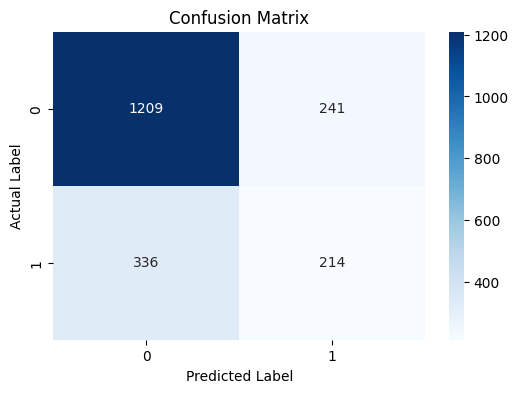

In [72]:
cm_3 = confusion_matrix(y_pred_3,y_test) 
plt.figure(figsize=(6,4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

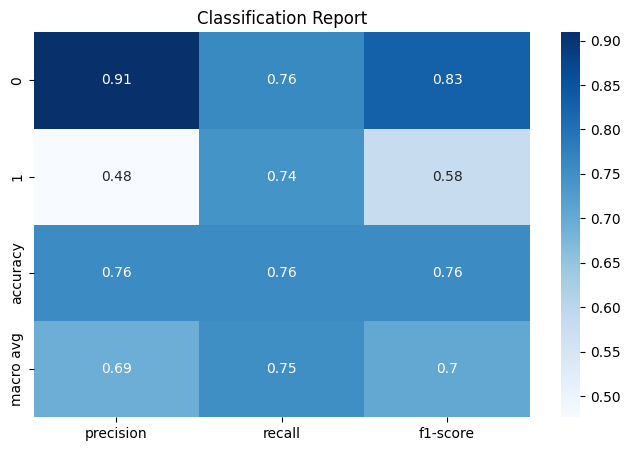

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt


report_3 = classification_report(y_test, y_pred_3, output_dict=True)
import pandas as pd

report_df_3 = pd.DataFrame(report).transpose()
plt.figure(figsize=(8,5))
sns.heatmap(report_df_3.iloc[:-1, :-1], annot=True, cmap="Blues")

plt.title("Classification Report")
plt.show()

In [74]:
train_score = model_3.score(X_train, y_train)
test_score = model_3.score(X_test, y_test) * 100

print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 1.0
Testing Score: 71.15


In [75]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

In [76]:
num_cols

Index(['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day',
       'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes',
       'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout'],
      dtype='object')

In [77]:
cat_cols = df.select_dtypes(include='object').columns

In [78]:
cat_cols


Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object')

df.head(1)

In [80]:
df.head(1)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.9,0.9,Year 1,Arts,High School,0
